## Step 1: Environment Setup

In [ ]:
# Check GPU is available
!nvidia-smi

# Install ultralytics (YOLOv8) and roboflow
!pip install ultralytics roboflow -q

import ultralytics
ultralytics.checks()

Ultralytics 8.4.121 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 52.2/118.9 GB disk)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path

# Create project directories in Google Drive (persistent across sessions)
project_dir = Path('/content/drive/MyDrive/pallet-pose')
project_dir.mkdir(parents=True, exist_ok=True)

for subdir in ['data/raw/dataset1', 'data/raw/dataset2', 'data/processed', 'data/splits', 'models', 'results']:
    (project_dir / subdir).mkdir(parents=True, exist_ok=True)

print(f'Project directory: {project_dir}')
print('Directory structure created.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directory: /content/drive/MyDrive/pallet-pose
Directory structure created.


In [1]:


ROBOFLOW_API_KEY = "OZJoYE17jGKJsisjgTQ0"  # ← Replace with your key

print("API key set.")

API key set.


In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key=ROBOFLOW_API_KEY)

# URL: https://universe.roboflow.com/david-akhihiero-pvxdr/pallet-dezmj
print("Downloading Dataset 1: Pallet Detection...")
ds1 = rf.workspace("david-akhihiero-pvxdr").project("pallet-dezmj").version(6).download(
    "yolov8",
    location=str(project_dir / 'data/raw/dataset1')
)
print(f"Dataset 1 downloaded to: {project_dir / 'data/raw/dataset1'}")

In [ ]:

# URL: https://universe.roboflow.com/tggsml2021/the-pallet-with-boxes
print("Downloading Dataset 2: Pallet with Boxes...")
ds2 = rf.workspace("tggsml2021").project("the-pallet-with-boxes").version(2).download(
    "yolov8",
    location=str(project_dir / 'data/raw/dataset2')
)
print(f"Dataset 2 downloaded to: {project_dir / 'data/raw/dataset2'}")

In [ ]:

import os

for ds_name in ['dataset1', 'dataset2']:
    ds_path = project_dir / 'data/raw' / ds_name
    print(f"\n {ds_name}")
    if not ds_path.exists():
        print("  Not found!")
        continue
    for item in sorted(ds_path.iterdir()):
        if item.is_dir():
            # Count images in each split
            img_dir = item / 'images'
            if img_dir.exists():
                count = len(list(img_dir.glob('*')))
                print(f"  {item.name}/images: {count} files")
        elif item.suffix == '.yaml':
            print(f"  {item.name}")
            with open(item) as f:
                print(f"    {f.read()[:200]}")

## Step 3: Merge and Split Datasets

We merge both datasets into one unified pool, then create a 70/15/15 train/val/test split.

In [ ]:
import shutil, random, yaml
from pathlib import Path

raw_dir = project_dir / 'data/raw'
processed_dir = project_dir / 'data/processed'
splits_dir = project_dir / 'data/splits'


all_images_dir = processed_dir / 'all_images'
all_labels_dir = processed_dir / 'all_labels'


if all_images_dir.exists():
    shutil.rmtree(all_images_dir)
if all_labels_dir.exists():
    shutil.rmtree(all_labels_dir)

all_images_dir.mkdir(parents=True, exist_ok=True)
all_labels_dir.mkdir(parents=True, exist_ok=True)

total = 0
dataset_stats = []

for ds_folder in sorted(raw_dir.iterdir()):
    if not ds_folder.is_dir():
        continue
    count = 0
    for split in ['train', 'valid', 'test']:
        img_dir = ds_folder / split / 'images'
        lbl_dir = ds_folder / split / 'labels'
        if not img_dir.exists():
            continue
        for img_file in img_dir.glob('*'):
            if img_file.suffix.lower() not in ['.jpg', '.jpeg', '.png']:
                continue
            # Prefix with dataset name to avoid collisions
            new_name = f"{ds_folder.name}_{img_file.name}"
            shutil.copy2(img_file, all_images_dir / new_name)
            lbl_file = lbl_dir / (img_file.stem + '.txt')
            if lbl_file.exists():
                shutil.copy2(lbl_file, all_labels_dir / new_name.replace(img_file.suffix, '.txt'))
            count += 1
    print(f"  {ds_folder.name}: {count} images")
    dataset_stats.append({'name': ds_folder.name, 'images': count})
    total += count

print(f"\n Total merged: {total} images")

In [ ]:
# Create train/val/test splits (70/15/15)
image_files = sorted([f.name for f in all_images_dir.iterdir()
                      if f.suffix.lower() in ['.jpg', '.jpeg', '.png']])

random.seed(42)
random.shuffle(image_files)

n = len(image_files)
n_train = int(n * 0.7)
n_val = int(n * 0.15)

splits = {
    'train': image_files[:n_train],
    'val': image_files[n_train:n_train+n_val],
    'test': image_files[n_train+n_val:],
}

# Clean previous splits
if splits_dir.exists():
    shutil.rmtree(splits_dir)
splits_dir.mkdir(parents=True, exist_ok=True)

for split_name, files in splits.items():
    for subdir in ['images', 'labels']:
        (splits_dir / split_name / subdir).mkdir(parents=True, exist_ok=True)
    for fname in files:
        shutil.copy2(all_images_dir / fname, splits_dir / split_name / 'images' / fname)
        lbl_name = fname.rsplit('.', 1)[0] + '.txt'
        lbl_path = all_labels_dir / lbl_name
        if lbl_path.exists():
            shutil.copy2(lbl_path, splits_dir / split_name / 'labels' / lbl_name)
    print(f"  {split_name}: {len(files)} images")

# Write data.yaml for YOLOv8
data_yaml = {
    'path': str(splits_dir),
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'names': {0: 'pallet'},
}
with open(splits_dir / 'data.yaml', 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f"\n Dataset ready at {splits_dir}")
print(f"  data.yaml written")
print(f"  Total: {n} images (train={n_train}, val={n_val}, test={n-n_train-n_val})")

In [ ]:
# ── FIX: Re-download datasets to local disk, then merge ──
import os, shutil, random, yaml
from pathlib import Path
from roboflow import Roboflow

ROBOFLOW_API_KEY = "OZJoYE17jGKJsisjgTQ0"
project_dir = Path('/content/drive/MyDrive/pallet-pose')


rf = Roboflow(api_key=ROBOFLOW_API_KEY)

print("Downloading Dataset 1: Pallet Detection...")
ds1 = rf.workspace("david-akhihiero-pvxdr").project("pallet-dezmj").version(6).download("yolov8")
print(f"  Saved to: {ds1.location}")

print("\nDownloading Dataset 2: Pallet with Boxes...")
ds2 = rf.workspace("tggsml2021").project("the-pallet-with-boxes").version(2).download("yolov8")
print(f"  Saved to: {ds2.location}")


print("\n--- Downloaded folders ---")
for name in ['Pallet-Detection-6', 'pallet-dezmj-6', 'the-pallet-with-boxes-2', 'Pallet-with-boxes-2']:
    p = Path('/content') / name
    if p.exists():
        print(f"  Found: {p}")
        for root, dirs, files in os.walk(str(p)):
            level = root.replace(str(p), '').count(os.sep)
            if level <= 2:
                indent = '  ' * (level + 1)
                print(f"{indent}{os.path.basename(root)}/ ({len(files)} files)")


ds_folders = []
for item in Path('/content').iterdir():
    if not item.is_dir() or item.name in ['.config', 'drive', 'sample_data', '.ipynb_checkpoints', 'models']:
        continue
    # Check if it has train/ or train/images/
    if (item / 'train').exists() or (item / 'train' / 'images').exists():
        ds_folders.append(item)
        print(f"\n Dataset folder found: {item}")

# ── Merge into one pool ──
processed_dir = project_dir / 'data/processed'
splits_dir = project_dir / 'data/splits'
all_images_dir = processed_dir / 'all_images'
all_labels_dir = processed_dir / 'all_labels'

# Clean previous
for d in [all_images_dir, all_labels_dir, splits_dir]:
    if d.exists():
        shutil.rmtree(d)
all_images_dir.mkdir(parents=True, exist_ok=True)
all_labels_dir.mkdir(parents=True, exist_ok=True)

total = 0
for ds_folder in ds_folders:
    count = 0
    for split in ['train', 'valid', 'test']:
        img_dir = ds_folder / split / 'images'
        lbl_dir = ds_folder / split / 'labels'
        if not img_dir.exists():
            continue
        for img_file in img_dir.glob('*'):
            if img_file.suffix.lower() not in ['.jpg', '.jpeg', '.png']:
                continue
            new_name = f"{ds_folder.name}_{img_file.name}"
            shutil.copy2(img_file, all_images_dir / new_name)
            lbl_file = lbl_dir / (img_file.stem + '.txt')
            if lbl_file.exists():
                shutil.copy2(lbl_file, all_labels_dir / new_name.replace(img_file.suffix, '.txt'))
            count += 1
    print(f"  {ds_folder.name}: {count} images")
    total += count

print(f"\n Total merged: {total} images")

# ── Create splits ──
image_files = sorted([f.name for f in all_images_dir.iterdir()
                      if f.suffix.lower() in ['.jpg', '.jpeg', '.png']])
random.seed(42)
random.shuffle(image_files)

n = len(image_files)
n_train = int(n * 0.7)
n_val = int(n * 0.15)

splits = {
    'train': image_files[:n_train],
    'val': image_files[n_train:n_train+n_val],
    'test': image_files[n_train+n_val:],
}

splits_dir.mkdir(parents=True, exist_ok=True)
for split_name, files in splits.items():
    for subdir in ['images', 'labels']:
        (splits_dir / split_name / subdir).mkdir(parents=True, exist_ok=True)
    for fname in files:
        shutil.copy2(all_images_dir / fname, splits_dir / split_name / 'images' / fname)
        lbl_name = fname.rsplit('.', 1)[0] + '.txt'
        lbl_path = all_labels_dir / lbl_name
        if lbl_path.exists():
            shutil.copy2(lbl_path, splits_dir / split_name / 'labels' / lbl_name)
    print(f"  {split_name}: {len(files)} images")

# ── Write data.yaml ──
data_yaml = {
    'path': str(splits_dir),
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'names': {0: 'pallet'},
}
with open(splits_dir / 'data.yaml', 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f"\n Dataset ready! {n} images total (train={n_train}, val={n_val}, test={n-n_train-n_val})")
print(f"  data.yaml at: {splits_dir / 'data.yaml'}")


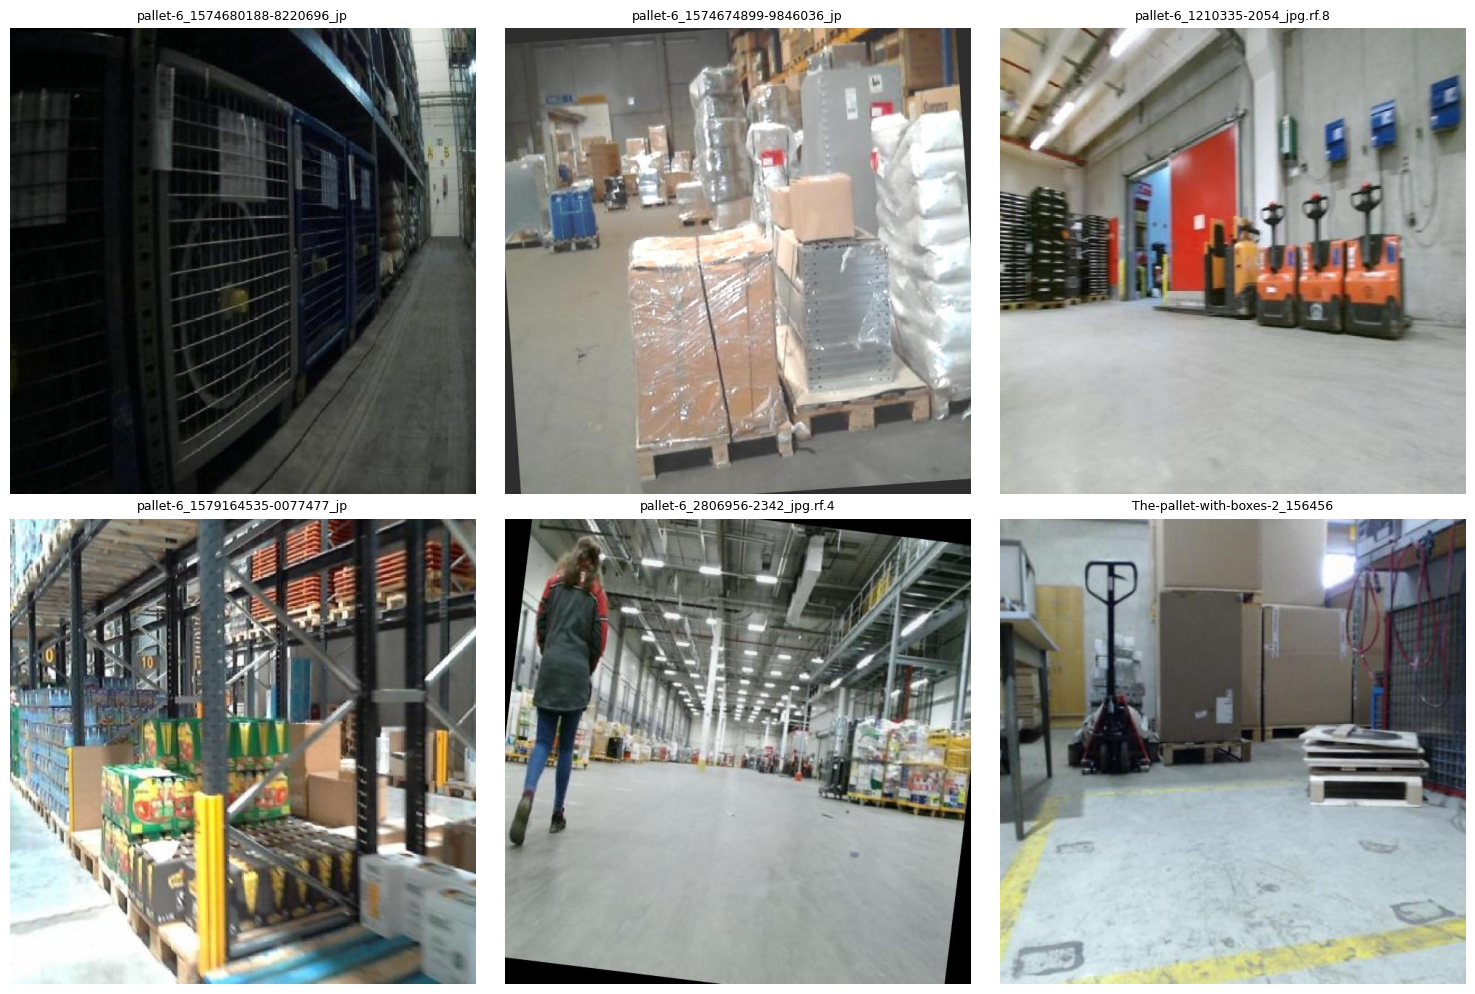

Sample images saved.


In [ ]:
# Visualize a few samples
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

train_images = list((splits_dir / 'train/images').glob('*'))
sample = random.sample(train_images, min(6, len(train_images)))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, img_path in zip(axes.ravel(), sample):
    img = mpimg.imread(str(img_path))
    ax.imshow(img)
    ax.set_title(img_path.name[:30], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig(str(project_dir / 'results/sample_images.png'), dpi=100)
plt.show()
print("Sample images saved.")

## Step 4: Train YOLOv8

Using **YOLOv8s** (Small) — good balance of accuracy and speed for the T4 GPU.

Training takes ~30-60 minutes on T4 depending on dataset size.

In [ ]:
from ultralytics import YOLO

# Load a pretrained YOLOv8s model
model = YOLO('yolov8s.pt')

# Train!
results = model.train(
    data=str(splits_dir / 'data.yaml'),
    epochs=150,
    imgsz=640,
    batch=16,
    device=0,          # GPU
    patience=30,        # Early stopping if no improvement for 30 epochs
    project=str(project_dir / 'models'),
    name='pallet_detection',
    save=True,
    plots=True,        # Generate training plots
)

print("\n Training complete!")
best_weights = project_dir / 'models' / 'pallet_detection' / 'weights' / 'best.pt'
print(f"Best weights: {best_weights}")

## Step 5: Evaluate on Test Set

In [ ]:
# ── FIXED: Load correct weights and evaluate ──
from ultralytics import YOLO

# Use the correct path (pallet_detection-2)
best_weights = str(project_dir / 'models' / 'pallet_detection-2' / 'weights' / 'best.pt')
model = YOLO(best_weights)

# Run validation on test set
metrics = model.val(data=str(splits_dir / 'data.yaml'), split='test')

print(f"\n Detection Results:")
print(f"  mAP@0.5:       {metrics.box.map50:.4f}")
print(f"  mAP@0.5:0.95:  {metrics.box.map:.4f}")
print(f"  Precision:      {metrics.box.mp:.4f}")
print(f"  Recall:         {metrics.box.mr:.4f}")


In [ ]:
# Show training results plot
from IPython.display import Image, display

results_dir = project_dir / 'models' / 'pallet_detection'

if (results_dir / 'results.png').exists():
    print("Training curves:")
    display(Image(filename=str(results_dir / 'results.png')))

In [ ]:
# Show confusion matrix
if (results_dir / 'confusion_matrix.png').exists():
    print("Confusion matrix:")
    display(Image(filename=str(results_dir / 'confusion_matrix.png')))


image 1/1 /content/drive/MyDrive/pallet-pose/data/splits/test/images/The-pallet-with-boxes-2_1564562812-4701054_jpg.rf.a61bd54e5deb05264771551d3db58220.jpg: 640x640 1 pallet, 16.0ms
Speed: 4.3ms preprocess, 16.0ms inference, 2.8ms postprocess per image at shape (1, 3, 640, 640)


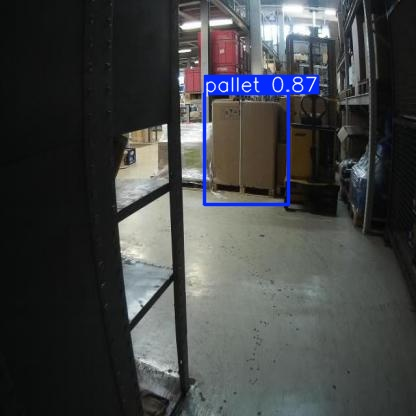


image 1/1 /content/drive/MyDrive/pallet-pose/data/splits/test/images/The-pallet-with-boxes-2_1564563279-4191911_jpg.rf.1ad9cbf0b6a9150e5a733f67e9c66edb.jpg: 640x640 4 pallets, 15.9ms
Speed: 3.6ms preprocess, 15.9ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 640)


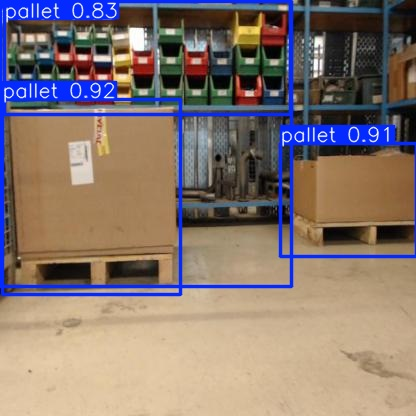


image 1/1 /content/drive/MyDrive/pallet-pose/data/splits/test/images/The-pallet-with-boxes-2_1564563290-5847032_jpg.rf.98b76a6cc5aaf2afbc3737ceae1b7c82.jpg: 640x640 2 pallets, 15.8ms
Speed: 2.5ms preprocess, 15.8ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


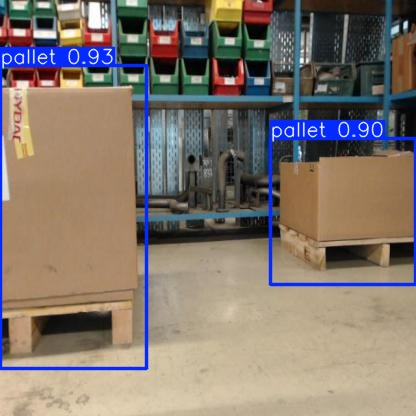


image 1/1 /content/drive/MyDrive/pallet-pose/data/splits/test/images/The-pallet-with-boxes-2_1564563297-6967568_jpg.rf.037f7385521b570b0e3ca0b1d89b07f6.jpg: 640x640 2 pallets, 15.8ms
Speed: 2.6ms preprocess, 15.8ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


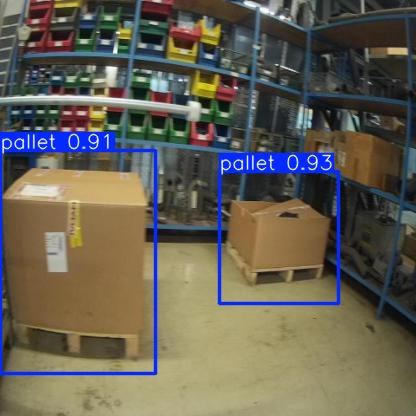


image 1/1 /content/drive/MyDrive/pallet-pose/data/splits/test/images/The-pallet-with-boxes-2_1564563412-56605_jpg.rf.93f02842cf8f785134cf8bd861835c9e.jpg: 640x640 2 pallets, 15.8ms
Speed: 3.6ms preprocess, 15.8ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


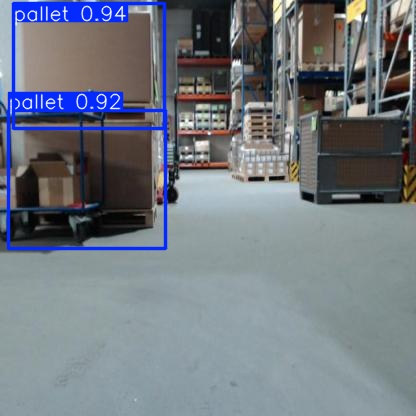

In [ ]:
# Run inference on a few test images and display results
import glob

test_images = sorted(glob.glob(str(splits_dir / 'test/images/*.jpg')))[:5]

for img_path in test_images:
    results = model(img_path, conf=0.5)
    annotated_path = img_path.replace('.jpg', '_pred.jpg')
    results[0].save(filename=annotated_path)
    display(Image(filename=annotated_path))

## Step 6: Collect Confidence Distribution

The rubric requires reporting distributions, not point estimates. We collect all detection confidences on the test set.

Collected 577 detections from 156 test images


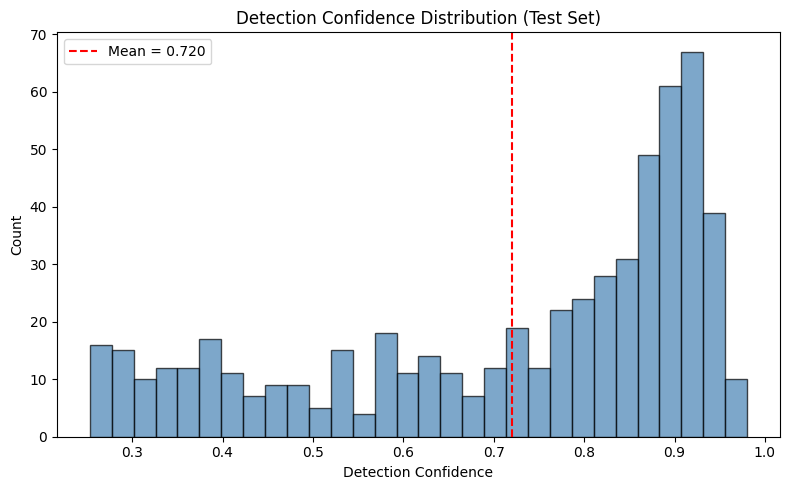

Saved to results/confidence_distribution.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

all_confidences = []

test_images = sorted(glob.glob(str(splits_dir / 'test/images/*.jpg')))
for img_path in test_images:
    results = model(img_path, conf=0.25, verbose=False)
    for result in results:
        for conf in result.boxes.conf.cpu().numpy():
            all_confidences.append(float(conf))

print(f"Collected {len(all_confidences)} detections from {len(test_images)} test images")

# Plot confidence distribution
plt.figure(figsize=(8, 5))
plt.hist(all_confidences, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Detection Confidence')
plt.ylabel('Count')
plt.title('Detection Confidence Distribution (Test Set)')
plt.axvline(np.mean(all_confidences), color='red', linestyle='--',
            label=f'Mean = {np.mean(all_confidences):.3f}')
plt.legend()
plt.tight_layout()
plt.savefig(str(project_dir / 'results/confidence_distribution.png'), dpi=150)
plt.show()
print("Saved to results/confidence_distribution.png")

## Step 7: Export to ONNX

ONNX export allows running the model with ONNX Runtime on CPU/GPU without PyTorch.
This is needed for the deployment section of the assignment.

In [ ]:
# Export to ONNX
onnx_path = model.export(format='onnx', imgsz=640)
print(f" ONNX model exported: {onnx_path}")

# Copy to models directory
import shutil
shutil.copy2(onnx_path, project_dir / 'models' / 'best.onnx')
print(f"Copied to: {project_dir / 'models' / 'best.onnx'}")

## Step 8: Download Trained Weights

Download the `.pt` and `.onnx` files to your local machine.
Place them in the `models/` folder of your project repo.

In [ ]:
from google.colab import files

# Download best.pt from CORRECT path (pallet_detection-2)
print("Downloading best.pt...")
files.download(str(project_dir / 'models' / 'pallet_detection-2' / 'weights' / 'best.pt'))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Download best.onnx
print("Downloading best.onnx...")
files.download(str(project_dir / 'models' / 'best.onnx'))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
import glob
from pathlib import Path

# Redefine the path (in case session was reset)
project_dir = Path('/content/drive/MyDrive/pallet-pose')

# Find and download 5 test images
test_images = sorted(glob.glob(str(project_dir / 'data/splits/test/images/*.jpg')))[:5]

if len(test_images) == 0:
    print("No test images found! Checking what's in the splits folder...")
    splits_dir = project_dir / 'data/splits'
    if splits_dir.exists():
        for root, dirs, files in __import__('os').walk(str(splits_dir)):
            print(f"  {root}: {len(files)} files")
    else:
        print("  splits/ folder doesn't exist!")
else:
    for img_path in test_images:
        print(f"Downloading {img_path}...")
        files.download(img_path)


No test images found! Checking what's in the splits folder...
  splits/ folder doesn't exist!
